# Hyperparameter Tuning

**WICHTIG**
Dieses Notebook soll nicht nocheinmal komplet durchlaufen werden lassen. Denn das Tuning dauerte 45 Minuten!

## 1. Bibliotheken Import

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt
import json
from pathlib import Path
import joblib

## 1. Daten Einlesen

In [ ]:
BASE = "/content/drive/MyDrive/Model_data"

train_data = np.load(f"{BASE}/train_split1_100WS.npz")
X_train_raw = train_data["X"]
y_train_raw = train_data["y"]

test_data = np.load(f"{BASE}/test_split1_100WS.npz")
X_test_raw = test_data["X"]
y_test_raw = test_data["y"]

CHANNEL_NAMES = [
    "x_acc", "y_acc", "z_acc",
    "x_gyr", "y_gyr", "z_gyr",
    "qx", "qy", "qz", "qw",
    "roll", "pitch", "yaw"
]

print(f"X_train: {X_train_raw.shape}  y_train: {y_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}  y_test:  {y_test_raw.shape}")
print(f"Klassen: {np.unique(y_train_raw)}")

## 2. Feature Engineering

In [ ]:
def feature_engineering(X):
    # Berechnung von Mittelwert, Standardabweichung, Minimum und Maximum, Median, IQR, RMS, Range, 
    # Mittlere absolute Abweichung, Zero-Crossing-Rate, Steigung für jedes Fenster
    features = []
    for window in X:
        feature_vector = []
        for channel in range(window.shape[1]):
            #Mittelwert
            feature_vector.append(np.mean(window[:, channel]))
            #Standardabweichung
            feature_vector.append(np.std(window[:, channel]))
            #Minimum
            feature_vector.append(np.min(window[:, channel]))
            #Maximum
            feature_vector.append(np.max(window[:, channel]))
            #Median
            feature_vector.append(np.median(window[:, channel]))
            #Interquartilsabstand
            feature_vector.append(np.percentile(window[:, channel], 75) - np.percentile(window[:, channel], 25))
            #Root Mean Square
            feature_vector.append(np.sqrt(np.mean(window[:, channel]**2)))
            #Range
            feature_vector.append(np.max(window[:, channel]) - np.min(window[:, channel]))
            #Mittlere absolute Abweichung
            feature_vector.append(np.mean(np.abs(np.diff(window[:, channel]))))
            #Zero-Crossing-Rate
            zentriert = window[:, channel] - np.mean(window[:, channel])
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            #Steigung
            zeitachse = np.arange(len(window[:, channel]))
            if np.std(window[:, channel]) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, window[:, channel], 1)[0])
        
        #Vektorbetrag für Accelerometer und Gyroskop
        Accelerometer_vektor_betrag = np.sqrt(window[:, 0]**2 + window[:, 1]**2 + window[:, 2]**2)
        Gyroskop_vektor_betrag = np.sqrt(window[:, 3]**2 + window[:, 4]**2 + window[:, 5]**2)

        # 11 Features für Accelerometer-Betrag
        for betrag in [Accelerometer_vektor_betrag, Gyroskop_vektor_betrag]:
            feature_vector.append(np.mean(betrag))
            feature_vector.append(np.std(betrag))
            feature_vector.append(np.min(betrag))
            feature_vector.append(np.max(betrag))
            feature_vector.append(np.median(betrag))
            feature_vector.append(np.percentile(betrag, 75) - np.percentile(betrag, 25))
            feature_vector.append(np.sqrt(np.mean(betrag**2)))
            feature_vector.append(np.max(betrag) - np.min(betrag))
            feature_vector.append(np.mean(np.abs(np.diff(betrag))))
            zentriert = betrag - np.mean(betrag)
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            zeitachse = np.arange(len(betrag))
            if np.std(betrag) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, betrag, 1)[0])


        features.append(feature_vector)
        
    return np.array(features)

In [ ]:
X_train_features = feature_engineering(X_train_raw)
X_test_features  = feature_engineering(X_test_raw)
print("Features berechnet:", X_train_features.shape, X_test_features.shape)

In [ ]:
out_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")
out_dir.mkdir(parents=True, exist_ok=True)

np.savez_compressed(out_dir / "features_train_100WS.npz", X=X_train_features, y=y_train_raw)
np.savez_compressed(out_dir / "features_test_100WS.npz", X=X_test_features, y=y_test_raw)
print("Gespeichert:", out_dir / "features_train_100WS.npz", out_dir / "features_test_100WS.npz")

## 3. Daten einlesen und train_validate_test split

In [ ]:
BASE = "/content/drive/MyDrive/Model_data/ML_Daten"
train_f = np.load(f"{BASE}/features_train_100WS.npz")
test_f  = np.load(f"{BASE}/features_test_100WS.npz")


X_train_feat = train_f["X"]
y_train_raw = train_f["y"]


X_test_feat = test_f["X"]
y_test_raw = test_f["y"]

#Splitten der Trainingsdaten in Trainings- und Validierungsset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_feat, y_train_raw,
    test_size=0.15,
    stratify=y_train_raw,
    random_state=42
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded   = le.transform(y_val)
y_test_encoded  = le.transform(y_test_raw)
class_names = le.classes_

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_feat)

## 4. Random Forest Hyperparameter-Tuning 

**Nich nochmals ausführen, ausser das Json ging verloren!!**

In [ ]:
param_dist = {
    "n_estimators":     randint(100, 800),
    "max_depth":        randint(5, 30),        # oder None erlauben
    "min_samples_leaf": randint(1, 20),
    "max_features":     ["sqrt", "log2", 0.3, 0.5],
    "class_weight":     ["balanced", "balanced_subsample"]
}

base_model = RandomForestClassifier(random_state=42)

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average="macro")
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_f1 = random_search.fit(X_train_scaled, y_train_encoded)
search_params = random_search.best_params_
print("\nBeste Hyperparameter-Kombination:")
for param, value in search_params.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")

#Daten Speichern
out_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")
out_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "best_params": random_search.best_params_,
    "best_cv_score_macro_f1": float(random_search.best_score_),
}
with open(out_dir / "best_hyperparameters_random_forest_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir / "best_hyperparameters_random_forest_100WS.json")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Beste Hyperparameter-Kombination:
class_weight: balanced_subsample
max_depth: 24
max_features: log2
min_samples_leaf: 3
n_estimators: 211
Gespeichert: ..\..\Model_data\ML_Daten\best_hyperparameters.json


### Daten aus dem Json herausholen

In [ ]:
data_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")

with open(data_dir / "best_hyperparameters_random_forest_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

Train: (12570, 165) Test: (10273, 165)
Klassen: [np.str_('Auto'), np.str_('Laufen'), np.str_('Lift'), np.str_('Roundkick'), np.str_('Treppe'), np.str_('Velo'), np.str_('Zug')]
best_params geladen: {'class_weight': 'balanced_subsample', 'max_depth': 24, 'max_features': 'log2', 'min_samples_leaf': 3, 'n_estimators': 211}
Bestes CV-Score (macro F1): 0.9608415351824517


### Model in Joblib speichern

In [ ]:
best_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path("/content/drive/MyDrive/Model_data/ML_Daten/final_model_random_forest_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)


Validation-Set Performance:
              precision    recall  f1-score   support

        Auto       0.99      1.00      0.99       625
      Laufen       0.97      0.99      0.98       564
        Lift       0.97      0.95      0.96        87
   Roundkick       0.91      1.00      0.95        51
      Treppe       0.97      0.82      0.89        88
        Velo       0.98      0.97      0.97       215
         Zug       0.99      0.98      0.99       589

    accuracy                           0.98      2219
   macro avg       0.97      0.96      0.96      2219
weighted avg       0.98      0.98      0.98      2219


=== FINALE TEST PERFORMANCE ===
              precision    recall  f1-score   support

        Auto       0.93      0.15      0.26      1944
      Laufen       0.62      0.99      0.77      1529
        Lift       1.00      0.90      0.95       936
   Roundkick       0.99      0.84      0.91       132
      Treppe       0.67      0.49      0.57       263
        Velo    

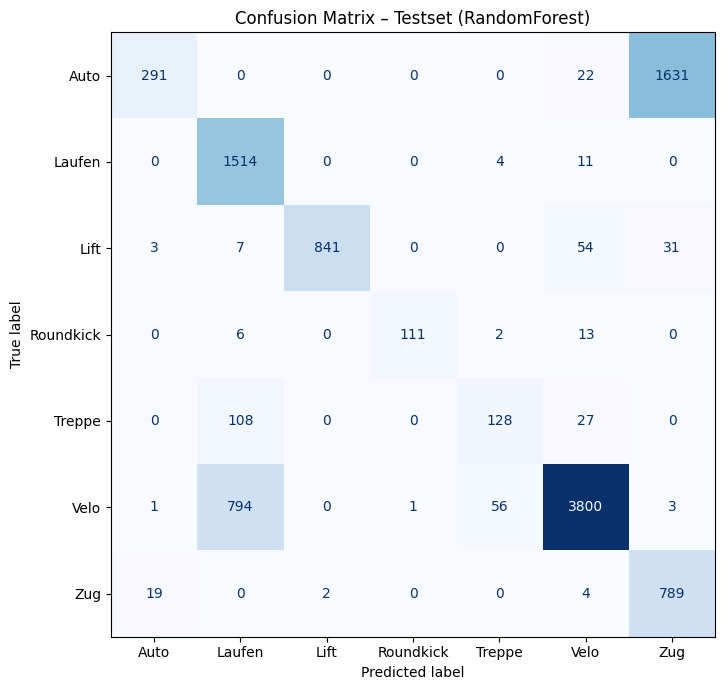

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – Testset (RandomForest)")
plt.tight_layout()
plt.show()

## 5. HistGradientBoosting Hyperparameter Tuning

In [ ]:
param_dist_hgb = {
    "max_iter":        randint(100, 800),
    "max_depth":       randint(3, 20),
    "min_samples_leaf": randint(1, 50),
    "learning_rate":   loguniform(0.01, 0.3),
    "l2_regularization": loguniform(1e-6, 10),
    "max_bins":        [63, 127, 255],
    "class_weight":    ["balanced", None]
}

base_model_hgb = HistGradientBoostingClassifier(random_state=42)

random_search_hgb = RandomizedSearchCV(
    estimator=base_model_hgb,
    param_distributions=param_dist_hgb,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_hgb = random_search_hgb.fit(X_train_scaled, y_train_encoded)
search_params_hgb = random_search_hgb.best_params_
print("\nBeste Hyperparameter-Kombination (HistGradientBoosting):")
for param, value in search_params_hgb.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")

out_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")
out_dir.mkdir(parents=True, exist_ok=True)

payload_hgb = {
    "best_params": random_search_hgb.best_params_,
    "best_cv_score_macro_f1": float(random_search_hgb.best_score_),
}
with open(out_dir / "best_hyperparameters_hgb_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload_hgb, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir / "best_hyperparameters_hgb_100WS.json")

### Daten aus dem Json herausholen

In [ ]:
data_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")

with open(data_dir / "best_hyperparameters_hgb_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

### Model in Joblib speichern

In [ ]:
best_model = HistGradientBoostingClassifier(
    **best_params,
    random_state=42)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path("/content/drive/MyDrive/Model_data/ML_Daten/final_model_hist_gradient_boosting_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)

## 6. SVM Hyperparameter Tuning

In [ ]:
param_dist_svm = {
    "C":           loguniform(0.1, 1000),
    "gamma":       loguniform(1e-4, 1),
    "kernel":      ["rbf"],
    "class_weight": ["balanced", None]
}

base_model_svm = SVC(random_state=42, probability=False)

random_search_svm = RandomizedSearchCV(
    estimator=base_model_svm,
    param_distributions=param_dist_svm,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_svm = random_search_svm.fit(X_train_scaled, y_train_encoded)
search_params_svm = random_search_svm.best_params_
print("\nBeste Hyperparameter-Kombination (SVM RBF):")
for param, value in search_params_svm.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")

out_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")
out_dir.mkdir(parents=True, exist_ok=True)

payload_svm = {
    "best_params": random_search_svm.best_params_,
    "best_cv_score_macro_f1": float(random_search_svm.best_score_),
}
with open(out_dir / "best_hyperparameters_svm_rbf_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload_svm, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir / "best_hyperparameters_svm_rbf_100WS.json")

### Daten aus Json herausholen

In [ ]:
data_dir = Path("/content/drive/MyDrive/Model_data/ML_Daten")

with open(data_dir / "best_hyperparameters_svm_rbf_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

### Model in Joblib speichern

In [ ]:
best_model = SVC(
    **best_params,
    random_state=42)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path("/content/drive/MyDrive/Model_data/ML_Daten/final_model_svm_rbf_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)